In [3]:
# 1. Variables and types

price_eur_mwh = 85.40
hour = 14
is_peak = True
market = "SDAC"
print(f"Hour {hour}: {price_eur_mwh} EUR/MWh, peak={is_peak}, market={market}")

Hour 14: 85.4 EUR/MWh, peak=True, market=SDAC


In [4]:
# 2. Lists

hourly_prices = [45.2, 42.1, 40.5, 39.8, 41.0, 48.5, 62.3, 78.9, 85.4, 82.1]
print(f"Number of hours: {len(hourly_prices)}")
print(f"Maximum price: {max(hourly_prices)}")
print(f"Minimum price: {min(hourly_prices)}")

Number of hours: 10
Maximum price: 85.4
Minimum price: 39.8


In [5]:
# 3. Loops

for i, price in enumerate(hourly_prices):
    if price > 70:
        print(f"Hour {i}: HIGH price {price} EUR/MWh")

Hour 7: HIGH price 78.9 EUR/MWh
Hour 8: HIGH price 85.4 EUR/MWh
Hour 9: HIGH price 82.1 EUR/MWh


In [6]:
# 4. Dictionaries

market_info = {
    "country": "Slovenia",
    "zone": "SI",
    "nemo": "BSP",
    "coupling": "SDAC"
}
for key, value in market_info.items():
    print(f"{key}: {value}")

country: Slovenia
zone: SI
nemo: BSP
coupling: SDAC


In [7]:
# Day 1 Exercise: Create a list of 24 made-up hourly prices. Write a loop that classifies each hour as "off-peak" (hours 0–7, 20–23), "peak" (8–19), and prints the average price for each category.

hourly_prices = [96, 97, 98, 103, 106, 112, 142, 157, 135, 99, 82, 59, 33, 38, 68, 91, 119, 146, 180, 182, 131, 126, 119, 113]

off_peak_prices = []
peak_prices = []

for hour, price in enumerate(hourly_prices):
    if hour <= 7 or hour >= 20:
        off_peak_prices.append(price)
    else:
        peak_prices.append(price)

off_peak_avg = sum(off_peak_prices) / len(off_peak_prices)
peak_avg = sum(peak_prices) / len(peak_prices)

print(round(off_peak_avg, 2))
print(round(peak_avg, 2))



116.67
102.67


In [8]:
# Create realistic SI day-ahead price data

import pandas as pd
import numpy as np
# Create realistic SI day-ahead price data (we'll replace with real data in Week 3-4)
np.random.seed(42)
dates = pd.date_range("2025-01-01", "2025-12-31", freq="h")
base = 65 + 15 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24)) # daily cycle
noise = np.random.normal(0, 10, len(dates))
seasonal = 10 * np.sin(np.arange(len(dates)) * 2 * np.pi / (365*24)) # yearly cycle
prices = base + noise + seasonal
prices = np.clip(prices, 0, 300) # no negative, cap spikes
df = pd.DataFrame({"timestamp": dates, "price_eur_mwh": prices})
import os
os.makedirs("../data/raw", exist_ok=True)
df.to_csv("../data/raw/si_da_prices_simulated.csv", index=False)

In [9]:
# Pandas basics

df = pd.read_csv("../data/raw/si_da_prices_simulated.csv", parse_dates=["timestamp"])
print(df.shape) # rows, columns
print(df.dtypes) # data types
print(df.head(10)) # first 10 rows
print(df.describe()) # summary statistics
print(df.isna().sum()) # missing values count

(8737, 2)
timestamp        datetime64[us]
price_eur_mwh           float64
dtype: object
            timestamp  price_eur_mwh
0 2025-01-01 00:00:00      69.967142
1 2025-01-01 01:00:00      67.506815
2 2025-01-01 02:00:00      78.991231
3 2025-01-01 03:00:00      90.858418
4 2025-01-01 04:00:00      75.677538
5 2025-01-01 05:00:00      77.183381
6 2025-01-01 06:00:00      95.835164
7 2025-01-01 07:00:00      87.213443
8 2025-01-01 08:00:00      73.353018
9 2025-01-01 09:00:00      81.096755
                 timestamp  price_eur_mwh
count                 8737    8737.000000
mean   2025-07-02 00:00:00      64.990143
min    2025-01-01 00:00:00       9.733551
25%    2025-04-02 00:00:00      53.678123
50%    2025-07-02 00:00:00      65.018032
75%    2025-10-01 00:00:00      76.401343
max    2025-12-31 00:00:00     120.581483
std                    NaN      16.310571
timestamp        0
price_eur_mwh    0
dtype: int64


In [10]:
# Day 2 Exercise: Find the hour with the highest price. Find the day with the highest average price. Print both.

df = pd.read_csv("../data/raw/si_da_prices_simulated.csv", parse_dates=["timestamp"])

# Find the row with the highest price
idx = df["price_eur_mwh"].idxmax()
highest_row = df.loc[idx]
print("Highest price hour:", highest_row["timestamp"], "Price:", highest_row["price_eur_mwh"])

# Add a date column (just the date part, no time)
df["date"] = df["timestamp"].dt.date

# Calculate average price per day
daily_avg = df.groupby("date")["price_eur_mwh"].mean()

# Find the day with the highest average
best_day = daily_avg.idxmax()
print("Highest avg price day:", best_day, "Avg price:", daily_avg[best_day].round(2))

Highest price hour: 2025-03-09 07:00:00 Price: 120.58148330645088
Highest avg price day: 2025-04-07 Avg price: 79.68


In [11]:
# Day 3 Pandas — filtering, grouping, time operations

df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.dayofweek # 0=Monday

# Filter: only peak hours (8-19)
peak = df[df["hour"].between(8, 19)]
offpeak = df[~df["hour"].between(8, 19)]

print(f"Peak avg: {peak['price_eur_mwh'].mean():.2f}")
print(f"Off-peak avg: {offpeak['price_eur_mwh'].mean():.2f}")

# Group by month
monthly = df.groupby("month")["price_eur_mwh"].agg(["mean", "std", "max"]).round(2)
print(monthly)

# Resample: daily averages
df_ts = df.set_index("timestamp")
daily = df_ts["price_eur_mwh"].resample("D").mean()
print(daily.head(10))


Peak avg: 61.42
Off-peak avg: 68.56
        mean    std     max
month                      
1      67.46  14.45  110.25
2      72.87  14.40  109.75
3      74.80  14.31  120.58
4      74.87  14.71  115.83
5      72.14  14.93  109.59
6      67.08  14.53  101.06
7      62.53  14.16  106.34
8      57.61  14.36   96.99
9      55.04  14.81   94.49
10     55.29  15.21  101.16
11     58.23  14.93   99.11
12     62.50  14.89  105.28
timestamp
2025-01-01    63.606100
2025-01-02    62.625032
2025-01-03    66.394907
2025-01-04    64.272739
2025-01-05    66.275308
2025-01-06    65.045132
2025-01-07    68.230221
2025-01-08    66.577577
2025-01-09    69.622776
2025-01-10    65.660152
Freq: D, Name: price_eur_mwh, dtype: float64


In [12]:
# Day 3 Exercise: Calculate the average peak-vs-offpeak spread for each month.

# Step 1: Extract time components from timestamp
df["date"] = df["timestamp"].dt.date        # just the date
df["hour"] = df["timestamp"].dt.hour        # hour 0-23
df["month"] = df["timestamp"].dt.month      # month 1-12
df["weekday"] = df["timestamp"].dt.dayofweek  # 0=Monday, 6=Sunday

# Step 2: Filter peak and offpeak hours
peak = df[df["hour"].between(8, 19)]        # hours 8-19 = peak
offpeak = df[~df["hour"].between(8, 19)]    # everything else = offpeak

# Step 3: Calculate average price per month for each group
peak_monthly = peak.groupby("month")["price_eur_mwh"].mean()
off_peak_monthly = offpeak.groupby("month")["price_eur_mwh"].mean()
# groupby("month") = group all rows by month
# ["price_eur_mwh"].mean() = calculate average price for each group

# Step 4: Calculate spread (absolute value so negative doesn't matter)
spread = (peak_monthly - off_peak_monthly).abs()

# Step 5: Print results
print(spread)
print("Biggest spread month:", spread.idxmax())


month
1     5.872385
2     7.479324
3     6.602385
4     7.189446
5     8.149801
6     7.835362
7     6.334289
8     7.561621
9     7.145418
10    7.892635
11    6.970175
12    6.701165
Name: price_eur_mwh, dtype: float64
Biggest spread month: 5


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

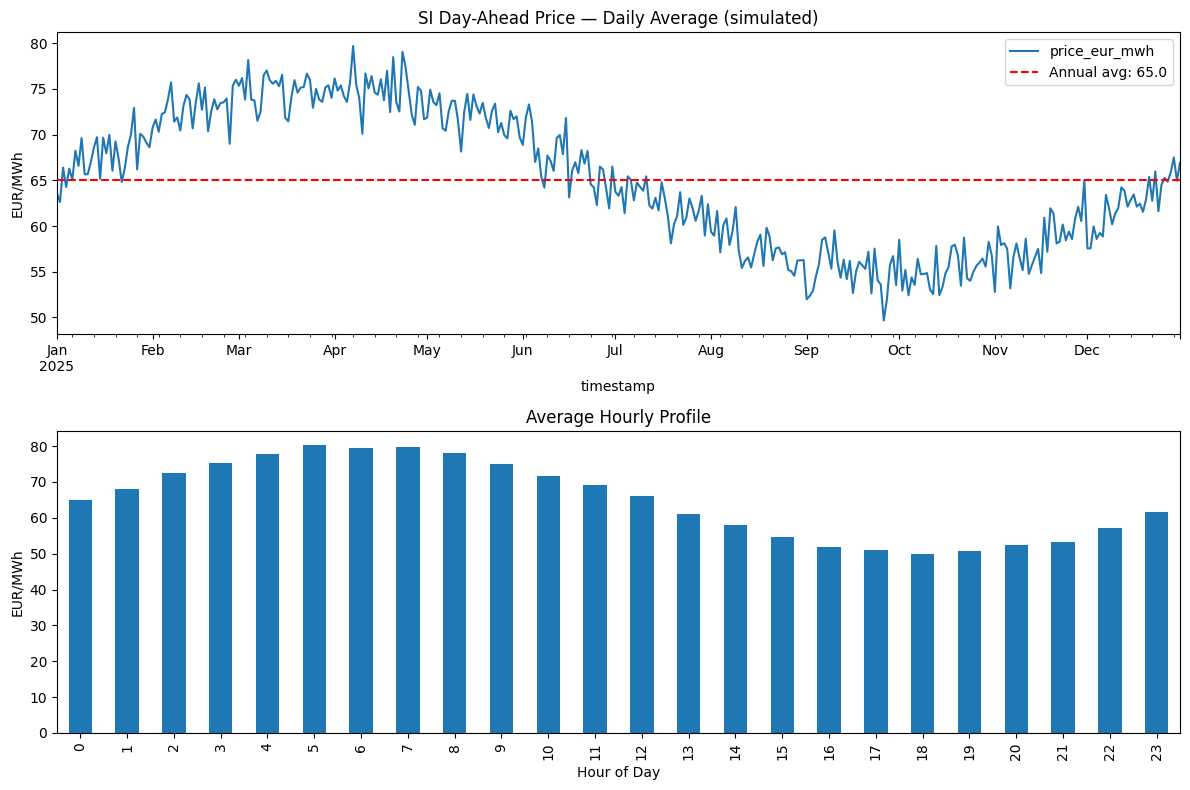

In [16]:
# Day 4 First plot — visualize the price curve

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Daily average prices over the year

daily.plot(ax=axes[0], title="SI Day-Ahead Price — Daily Average (simulated)")
axes[0].set_ylabel("EUR/MWh")
axes[0].axhline(daily.mean(), color="red", linestyle="--", label=f"Annual avg: {daily.mean():.1f}")
axes[0].legend()

# Typical daily profile (average by hour)

hourly_profile = df.groupby("hour")["price_eur_mwh"].mean()
hourly_profile.plot(kind="bar", ax=axes[1], title="Average Hourly Profile")
axes[1].set_ylabel("EUR/MWh")
axes[1].set_xlabel("Hour of Day")
plt.tight_layout()
plt.savefig("../docs/price_overview.png", dpi=150)
plt.show()


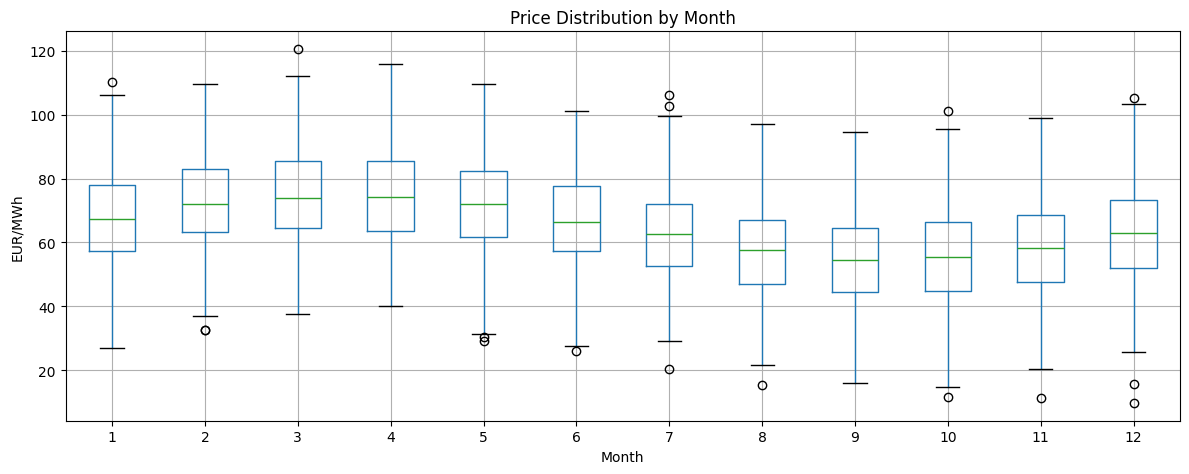

In [17]:
# Day 4 Exercise: Create a box plot showing price distribution by month. Add it to your docs/ folder.

import matplotlib.pyplot as plt

df["month"] = df["timestamp"].dt.month

fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column="price_eur_mwh", by="month", ax=ax)
ax.set_title("Price Distribution by Month")
ax.set_xlabel("Month")
ax.set_ylabel("EUR/MWh")
plt.suptitle("")  # removes the default pandas suptitle
plt.tight_layout()
plt.savefig("../docs/monthly_boxplot.png", dpi=150)
plt.show()

In [ ]:
# Day 5 SQL part 1 DuckDB on simulated prices

import duckdb

con = duckdb.connect("../data/energy.duckdb")

# Load your CSV directly into DuckDB
con.execute("""
    CREATE TABLE IF NOT EXISTS da_prices AS
    SELECT * FROM read_csv_auto('../data/raw/si_da_prices_simulated.csv')
""")

# Basic queries
print("--- Row count ---")
print(con.execute("SELECT COUNT(*) as n_rows FROM da_prices").fetchdf())

print("--- First 5 rows ---")
print(con.execute("SELECT * FROM da_prices LIMIT 5").fetchdf())

print("--- Monthly average ---")
print(con.execute("""
    SELECT
        MONTH(timestamp) as month,
        ROUND(AVG(price_eur_mwh), 2) as avg_price,
        ROUND(MAX(price_eur_mwh), 2) as max_price,
        COUNT(*) as hours
    FROM da_prices
    GROUP BY MONTH(timestamp)
    ORDER BY month
""").fetchdf())

--- Row count ---
   n_rows
0    8737
--- First 5 rows ---
            timestamp  price_eur_mwh
0 2025-01-01 00:00:00      69.967142
1 2025-01-01 01:00:00      67.506815
2 2025-01-01 02:00:00      78.991231
3 2025-01-01 03:00:00      90.858418
4 2025-01-01 04:00:00      75.677538
--- Monthly average ---
    month  avg_price  max_price  hours
0       1      67.46     110.25    744
1       2      72.87     109.75    672
2       3      74.80     120.58    744
3       4      74.87     115.83    720
4       5      72.14     109.59    744
5       6      67.08     101.06    720
6       7      62.53     106.34    744
7       8      57.61      96.99    744
8       9      55.04      94.49    720
9      10      55.29     101.16    744
10     11      58.23      99.11    720
11     12      62.50     105.28    721


In [ ]:
# Day 5 Exercise: Write a query that finds the top 10 most expensive hours. Write another that calculates the weekday vs weekend average price.

print("---The top 10 most expensive hours---")

print(con.execute("""
    SELECT
        timestamp,
        ROUND((price_eur_mwh), 2) as price
    FROM da_prices
    ORDER BY price_eur_mwh DESC
    LIMIT 10
""").fetchdf())

# The weekday vs weekend average price



---The top 10 most expensive hours---
            timestamp   price
0 2025-03-09 07:00:00  120.58
1 2025-04-18 06:00:00  115.83
2 2025-03-30 08:00:00  112.10
3 2025-04-15 10:00:00  111.74
4 2025-04-29 06:00:00  111.13
5 2025-01-28 06:00:00  110.25
6 2025-04-17 05:00:00  110.04
7 2025-03-04 03:00:00  109.96
8 2025-04-07 01:00:00  109.95
9 2025-03-10 06:00:00  109.85
